# 01 - Exploration et Nettoyage des Données

**Projet** : Scoring de Crédit et Prévision de Défauts  
**Auteur** : Shafin Hamjah (Data Engineer)  
**Date** : Janvier 2026

---

## Objectifs de ce notebook
1. Charger et explorer les données brutes
2. Analyser la qualité des données (types, valeurs manquantes, distributions)
3. Nettoyer les données (doublons, outliers, corrections de types)
4. Sauvegarder les données nettoyées

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

# Chemins
ROOT_DIR = Path('..')
RAW_DATA_PATH = ROOT_DIR / 'data' / 'raw' / 'credit_scoring_synth_130k_with_date_defaults.csv'
PROCESSED_DATA_PATH = ROOT_DIR / 'data' / 'processed'

print(f"Fichier de données : {RAW_DATA_PATH}")
print(f"Fichier existe : {RAW_DATA_PATH.exists()}")

Fichier de données : ..\data\raw\credit_scoring_synth_130k_with_date_defaults.csv
Fichier existe : True


## 1. Chargement des données

In [2]:
# Chargement
df = pd.read_csv(RAW_DATA_PATH)

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\nMémoire utilisée : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dimensions : 130,000 lignes × 66 colonnes

Mémoire utilisée : 73.57 MB


In [3]:
# Premières lignes
df.head()

,CLIENT_ID,TARGET,AGE,SEX,MARITAL_STATUS,CHILDREN_COUNT,EDUCATION_LEVEL,EMPLOYMENT_TYPE,SENIORITY_YEARS,IS_HOMEOWNER,HOUSING_TYPE,REGION,RESIDENCE_SINCE_YEARS,PHONE_VERIFIED,EMAIL_VERIFIED,HAS_CAR,NB_CREDIT_CARDS,HAS_PREVIOUS_DEFAULT,IS_FOREIGN_WORKER,CHANNEL,SEGMENT,DEVICE_OS,LOAN_AMOUNT,LOAN_TERM_MONTHS,INTEREST_RATE,INCOME_MONTHLY,EXPENSES_MONTHLY,MONTHLY_INSTALLMENT,DTI_RATIO,SAVINGS_BALANCE_M3,CHECKING_BALANCE_M3,SAVINGS_BALANCE_M2,CHECKING_BALANCE_M2,SAVINGS_BALANCE_M1,CHECKING_BALANCE_M1,AVG_BALANCE_3M,VAR_BALANCE_3M,NUM_LATE_PAYMENTS_12M,UTILIZATION_RATE,CREDIT_SCORE,NUM_OPEN_LOANS,TOTAL_CREDIT_LIMIT,LAST_WITHDRAWAL_AMOUNT,LAST_DEPOSIT_AMOUNT,POS_TXN_COUNT_30D,ATM_TXN_COUNT_30D,ONLINE_TXN_COUNT_30D,DAYS_SINCE_LAST_PAYMENT,INQUIRIES_6M,LTV_RATIO,INSURANCE_TAKEN,HAS_COAPPLICANT,EMPLOYMENT_GAP_MONTHS,PAYMENT_METHOD,BRANCH_VISITS_6M,MOBILE_LOGINS_30D,WEB_LOGINS_30D,APPROVAL_TIME_DAYS,MANUAL_REVIEW,GUARANTOR_PRESENT,RISK_BAND_INTERNAL,EXPENSES_TO_INCOME,INSTALLMENT_TO_INCOME,BALANCE_TO_LIMIT,DATE_MONTH,DEFAULTS_ORIGINATION
0,1,0,45,M,single,0,secondary,permanent,6.9,1,apartment,BRE,3.7,1,1,1,0,0,0,branch,mass,Android,36320.0,31,0.060168,2536.0,1213.0,1267.95,0.500,19486.0,-883.0,9247.0,-1298.0,19342.0,-168.0,15242.0,326725.00,0,0.289950,603.0,2,16351.0,80.64,791.69,23,4,14,80,0,0.111,0,0,1,Cash,2,8,5,0.4,1,0,C,0.478,0.500,0.932,2023-10-01,398
1,2,0,31,F,single,1,secondary,contractor,6.6,0,apartment,IDF,3.2,1,1,1,3,0,0,branch,affluent,iOS,36995.0,13,0.060992,4785.0,2891.0,2948.04,0.616,8543.0,1151.0,18804.0,2819.0,-46.0,4962.0,12078.0,3649732.33,1,0.497442,694.0,0,15592.0,250.00,437.94,19,6,13,58,3,0.305,1,1,1,SEPA,2,9,7,10.4,0,0,E,0.604,0.616,0.775,2021-06-01,378
2,3,0,50,M,single,0,master,permanent,3.6,1,apartment,BFC,0.0,0,1,1,0,0,1,branch,mass,Web,26151.0,73,0.070378,2573.0,1596.0,441.41,0.172,17106.0,839.0,11586.0,1304.0,17423.0,-99.0,16053.0,510746.33,0,0.548533,701.0,1,9787.0,125.07,388.10,26,6,13,40,3,0.128,0,0,3,Card,0,22,7,0.1,0,1,B,0.620,0.172,1.640,2021-11-01,363
3,4,0,52,M,married,0,secondary,permanent,5.3,0,apartment,HDF,0.9,1,1,1,4,0,0,online,affluent,Android,72576.0,47,0.049989,6862.0,3757.0,1703.47,0.248,15071.0,2327.0,6300.0,2249.0,9461.0,-1534.0,11291.0,4870749.00,0,0.647253,627.0,2,19332.0,200.43,289.61,19,4,13,75,1,0.299,1,0,2,Card,0,9,10,0.4,0,0,E,0.548,0.248,0.584,2022-09-01,431
4,5,0,21,F,single,1,secondary,permanent,8.3,1,house,PACA,9.2,1,0,1,2,0,0,agent,mass,iOS,25585.0,45,0.040316,5537.0,3531.0,613.57,0.111,11392.0,1119.0,23089.0,398.0,4421.0,4785.0,15068.0,5534194.33,0,0.373397,660.0,5,13022.0,225.66,209.37,19,4,12,82,2,0.092,1,0,3,SEPA,1,19,3,13.3,0,0,D,0.638,0.111,1.157,2025-02-01,357


In [4]:
# Liste des colonnes
print("Colonnes du dataset :")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

Colonnes du dataset :
 1. CLIENT_ID
 2. TARGET
 3. AGE
 4. SEX
 5. MARITAL_STATUS
 6. CHILDREN_COUNT
 7. EDUCATION_LEVEL
 8. EMPLOYMENT_TYPE
 9. SENIORITY_YEARS
10. IS_HOMEOWNER
11. HOUSING_TYPE
12. REGION
13. RESIDENCE_SINCE_YEARS
14. PHONE_VERIFIED
15. EMAIL_VERIFIED
16. HAS_CAR
17. NB_CREDIT_CARDS
18. HAS_PREVIOUS_DEFAULT
19. IS_FOREIGN_WORKER
20. CHANNEL
21. SEGMENT
22. DEVICE_OS
23. LOAN_AMOUNT
24. LOAN_TERM_MONTHS
25. INTEREST_RATE
26. INCOME_MONTHLY
27. EXPENSES_MONTHLY
28. MONTHLY_INSTALLMENT
29. DTI_RATIO
30. SAVINGS_BALANCE_M3
31. CHECKING_BALANCE_M3
32. SAVINGS_BALANCE_M2
33. CHECKING_BALANCE_M2
34. SAVINGS_BALANCE_M1
35. CHECKING_BALANCE_M1
36. AVG_BALANCE_3M
37. VAR_BALANCE_3M
38. NUM_LATE_PAYMENTS_12M
39. UTILIZATION_RATE
40. CREDIT_SCORE
41. NUM_OPEN_LOANS
42. TOTAL_CREDIT_LIMIT
43. LAST_WITHDRAWAL_AMOUNT
44. LAST_DEPOSIT_AMOUNT
45. POS_TXN_COUNT_30D
46. ATM_TXN_COUNT_30D
47. ONLINE_TXN_COUNT_30D
48. DAYS_SINCE_LAST_PAYMENT
49. INQUIRIES_6M
50. LTV_RATIO
51. INSURANCE_TA

## 2. Analyse de la structure des données

In [5]:
# Types de données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130000 entries, 0 to 129999
Data columns (total 66 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CLIENT_ID                130000 non-null  int64  
 1   TARGET                   130000 non-null  int64  
 2   AGE                      130000 non-null  int64  
 3   SEX                      130000 non-null  str    
 4   MARITAL_STATUS           130000 non-null  str    
 5   CHILDREN_COUNT           130000 non-null  int64  
 6   EDUCATION_LEVEL          130000 non-null  str    
 7   EMPLOYMENT_TYPE          130000 non-null  str    
 8   SENIORITY_YEARS          130000 non-null  float64
 9   IS_HOMEOWNER             130000 non-null  int64  
 10  HOUSING_TYPE             130000 non-null  str    
 11  REGION                   118941 non-null  str    
 12  RESIDENCE_SINCE_YEARS    130000 non-null  float64
 13  PHONE_VERIFIED           130000 non-null  int64  
 14  EMAIL_VERIFIED 

In [6]:
# Statistiques descriptives des variables numériques
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENT_ID,130000.0,6.500050e+04,3.752791e+04,1.000000,32500.750000,6.500050e+04,9.750025e+04,1.300000e+05
TARGET,130000.0,1.860000e-01,3.891082e-01,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
AGE,130000.0,4.201907e+01,1.089222e+01,18.000000,35.000000,4.200000e+01,4.900000e+01,8.500000e+01
CHILDREN_COUNT,130000.0,1.094992e+00,1.047330e+00,0.000000,0.000000,1.000000e+00,2.000000e+00,8.000000e+00
SENIORITY_YEARS,130000.0,4.995371e+00,4.985426e+00,0.000000,1.400000,3.500000e+00,6.900000e+00,4.000000e+01
IS_HOMEOWNER,130000.0,5.507077e-01,4.974240e-01,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00
RESIDENCE_SINCE_YEARS,130000.0,5.997539e+00,5.985186e+00,0.000000,1.700000,4.200000e+00,8.300000e+00,5.000000e+01
PHONE_VERIFIED,130000.0,9.000538e-01,2.999293e-01,0.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
EMAIL_VERIFIED,130000.0,8.496846e-01,3.573817e-01,0.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
HAS_CAR,130000.0,6.483923e-01,4.774741e-01,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00


In [7]:
# Statistiques des variables catégorielles
df.describe(include='object').T

,count,unique,top,freq
SEX,130000,2,M,65095
MARITAL_STATUS,130000,4,married,61242
EDUCATION_LEVEL,130000,5,secondary,54641
EMPLOYMENT_TYPE,130000,6,permanent,75087
HOUSING_TYPE,130000,3,house,71404
REGION,118941,11,BRE,10922
CHANNEL,130000,4,branch,58625
SEGMENT,130000,5,mass,78307
DEVICE_OS,130000,3,Web,43470
PAYMENT_METHOD,130000,4,SEPA,90810


## 3. Analyse de la variable cible (TARGET)

In [8]:
# Distribution de TARGET
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("Distribution de TARGET :")
print(f"  0 (Non défaut) : {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"  1 (Défaut)     : {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\n⚠️ Ratio de déséquilibre : 1:{target_counts[0]/target_counts[1]:.1f}")

Distribution de TARGET :
  0 (Non défaut) : 105,820 (81.40%)
  1 (Défaut)     : 24,180 (18.60%)

⚠️ Ratio de déséquilibre : 1:4.4


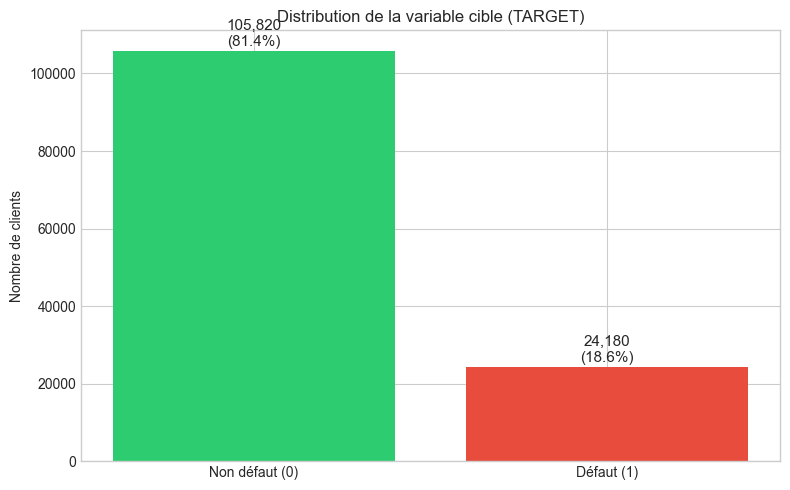

In [9]:
# Visualisation de TARGET
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Non défaut (0)', 'Défaut (1)'], target_counts.values, color=colors)

for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Nombre de clients')
ax.set_title('Distribution de la variable cible (TARGET)')
plt.tight_layout()
plt.savefig(ROOT_DIR / 'outputs' / 'figures' / 'target_distribution.png', dpi=150)
plt.show()

## 4. Analyse des valeurs manquantes

In [10]:
# Calcul des valeurs manquantes
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing.sort_values('missing_pct', ascending=False)

print(f"Total colonnes : {len(df.columns)}")
print(f"Colonnes avec valeurs manquantes : {(missing['missing_count'] > 0).sum()}")
print()

# ── Règle : supprimer les variables avec > 50% de valeurs manquantes ──
SEUIL_MISSING = 50.0
vars_to_drop_missing = missing[missing['missing_pct'] > SEUIL_MISSING].index.tolist()

if vars_to_drop_missing:
    print(f"⚠️  Variables supprimées (> {SEUIL_MISSING}% manquants) : {vars_to_drop_missing}")
    df = df.drop(columns=vars_to_drop_missing)
    print(f"Dimensions après suppression : {df.shape}")
else:
    print(f"✓ Aucune variable avec > {SEUIL_MISSING}% de valeurs manquantes.")

print()
print("Détail des valeurs manquantes restantes :")
missing_restant = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_restant = missing_restant[missing_restant['missing_count'] > 0].sort_values('missing_pct', ascending=False)
if len(missing_restant) > 0:
    print(missing_restant)
else:
    print("Aucune valeur manquante restante !")

Colonnes avec valeurs manquantes : 1
        missing_count  missing_pct
REGION          11059         8.51


In [11]:
# Vérifier les valeurs vides (chaînes vides, espaces)
object_cols = df.select_dtypes(include='object').columns
empty_values = {}

for col in object_cols:
    empty_count = (df[col].str.strip() == '').sum() if df[col].dtype == 'object' else 0
    if empty_count > 0:
        empty_values[col] = empty_count

if empty_values:
    print("Colonnes avec valeurs vides (chaînes vides) :")
    for col, count in empty_values.items():
        print(f"  {col}: {count} ({count/len(df)*100:.2f}%)")
else:
    print("Aucune chaîne vide détectée.")

Aucune chaîne vide détectée.


## 5. Analyse des doublons

In [12]:
# Vérifier les doublons complets
n_duplicates = df.duplicated().sum()
print(f"Doublons complets : {n_duplicates}")

# Vérifier les doublons sur CLIENT_ID
n_dup_clients = df.duplicated(subset=['CLIENT_ID']).sum()
print(f"Doublons sur CLIENT_ID : {n_dup_clients}")

if n_dup_clients > 0:
    print("\n⚠️ Clients avec plusieurs entrées :")
    dup_clients = df[df.duplicated(subset=['CLIENT_ID'], keep=False)]
    print(dup_clients.groupby('CLIENT_ID').size().head(10))

Doublons complets : 0
Doublons sur CLIENT_ID : 0


## 6. Analyse des types de données

In [13]:
# Catégorisation des variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numériques ({len(numeric_cols)}) :")
print(numeric_cols)
print(f"\nVariables catégorielles ({len(categorical_cols)}) :")
print(categorical_cols)

Variables numériques (54) :
['CLIENT_ID', 'TARGET', 'AGE', 'CHILDREN_COUNT', 'SENIORITY_YEARS', 'IS_HOMEOWNER', 'RESIDENCE_SINCE_YEARS', 'PHONE_VERIFIED', 'EMAIL_VERIFIED', 'HAS_CAR', 'NB_CREDIT_CARDS', 'HAS_PREVIOUS_DEFAULT', 'IS_FOREIGN_WORKER', 'LOAN_AMOUNT', 'LOAN_TERM_MONTHS', 'INTEREST_RATE', 'INCOME_MONTHLY', 'EXPENSES_MONTHLY', 'MONTHLY_INSTALLMENT', 'DTI_RATIO', 'SAVINGS_BALANCE_M3', 'CHECKING_BALANCE_M3', 'SAVINGS_BALANCE_M2', 'CHECKING_BALANCE_M2', 'SAVINGS_BALANCE_M1', 'CHECKING_BALANCE_M1', 'AVG_BALANCE_3M', 'VAR_BALANCE_3M', 'NUM_LATE_PAYMENTS_12M', 'UTILIZATION_RATE', 'CREDIT_SCORE', 'NUM_OPEN_LOANS', 'TOTAL_CREDIT_LIMIT', 'LAST_WITHDRAWAL_AMOUNT', 'LAST_DEPOSIT_AMOUNT', 'POS_TXN_COUNT_30D', 'ATM_TXN_COUNT_30D', 'ONLINE_TXN_COUNT_30D', 'DAYS_SINCE_LAST_PAYMENT', 'INQUIRIES_6M', 'LTV_RATIO', 'INSURANCE_TAKEN', 'HAS_COAPPLICANT', 'EMPLOYMENT_GAP_MONTHS', 'BRANCH_VISITS_6M', 'MOBILE_LOGINS_30D', 'WEB_LOGINS_30D', 'APPROVAL_TIME_DAYS', 'MANUAL_REVIEW', 'GUARANTOR_PRESENT', '

In [14]:
# Modalités des variables catégorielles
print("Modalités des variables catégorielles :\n")
for col in categorical_cols:
    unique_vals = df[col].nunique()
    print(f"{col} ({unique_vals} modalités) :")
    print(f"  {df[col].value_counts().head(10).to_dict()}")
    print()

Modalités des variables catégorielles :

SEX (2 modalités) :
  {'M': 65095, 'F': 64905}

MARITAL_STATUS (4 modalités) :
  {'married': 61242, 'single': 49409, 'divorced': 15502, 'widowed': 3847}

EDUCATION_LEVEL (5 modalités) :
  {'secondary': 54641, 'bachelor': 44100, 'master': 18340, 'primary': 10358, 'phd': 2561}

EMPLOYMENT_TYPE (6 modalités) :
  {'permanent': 75087, 'contractor': 19520, 'self_employed': 15666, 'unemployed': 8008, 'retired': 7891, 'student': 3828}

HOUSING_TYPE (3 modalités) :
  {'house': 71404, 'apartment': 54786, 'other': 3810}

REGION (11 modalités) :
  {'BRE': 10922, 'IDF': 10856, 'ARA': 10855, 'GE': 10849, 'NOR': 10848, 'HDF': 10842, 'OCC': 10842, 'PDL': 10830, 'CVL': 10752, 'BFC': 10700}

CHANNEL (4 modalités) :
  {'branch': 58625, 'online': 45186, 'agent': 19729, 'partner': 6460}

SEGMENT (5 modalités) :
  {'mass': 78307, 'affluent': 32302, 'student': 6508, 'private': 6492, 'senior': 6391}

DEVICE_OS (3 modalités) :
  {'Web': 43470, 'Android': 43302, 'iOS': 4

## 7. Analyse de la variable temporelle (DATE_MONTH)

In [15]:
# Convertir DATE_MONTH en datetime
df['DATE_MONTH'] = pd.to_datetime(df['DATE_MONTH'])

print(f"Période couverte : {df['DATE_MONTH'].min()} à {df['DATE_MONTH'].max()}")
print(f"Nombre de mois : {df['DATE_MONTH'].nunique()}")

Période couverte : 2021-01-01 00:00:00 à 2025-12-01 00:00:00
Nombre de mois : 60


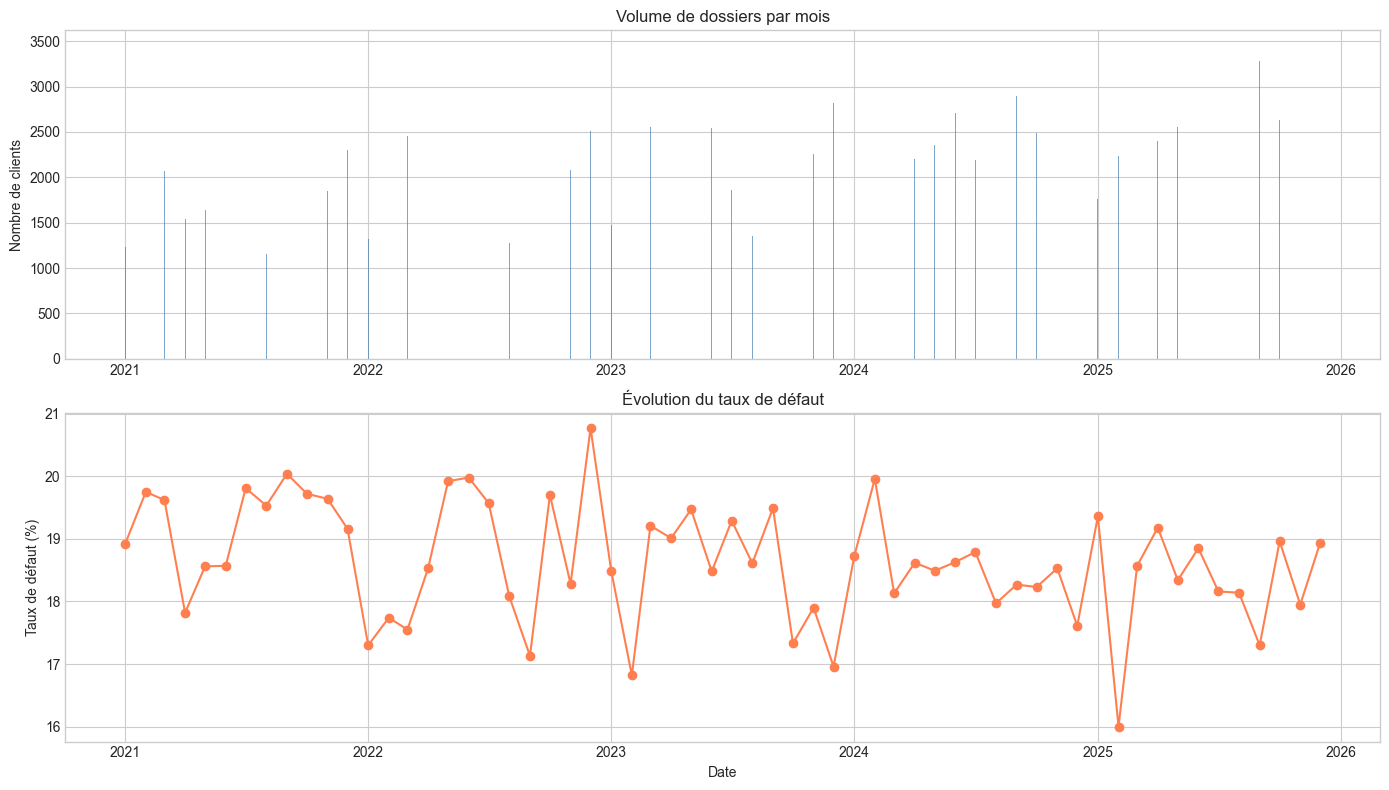

In [16]:
# Distribution temporelle
monthly_counts = df.groupby('DATE_MONTH').agg({
    'CLIENT_ID': 'count',
    'TARGET': 'sum'
}).rename(columns={'CLIENT_ID': 'nb_clients', 'TARGET': 'nb_defauts'})

monthly_counts['taux_defaut'] = (monthly_counts['nb_defauts'] / monthly_counts['nb_clients'] * 100).round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Volume par mois
axes[0].bar(monthly_counts.index, monthly_counts['nb_clients'], color='steelblue', alpha=0.7)
axes[0].set_ylabel('Nombre de clients')
axes[0].set_title('Volume de dossiers par mois')

# Taux de défaut par mois
axes[1].plot(monthly_counts.index, monthly_counts['taux_defaut'], marker='o', color='coral')
axes[1].set_ylabel('Taux de défaut (%)')
axes[1].set_title('Évolution du taux de défaut')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig(ROOT_DIR / 'outputs' / 'figures' / 'temporal_analysis.png', dpi=150)
plt.show()

## 8. Nettoyage des données

In [17]:
# Copie pour nettoyage
df_clean = df.copy()
print(f"Taille initiale : {len(df_clean):,} lignes")

Taille initiale : 130,000 lignes


In [18]:
# 8.1 Traitement des valeurs vides dans REGION
if 'REGION' in df_clean.columns:
    # Remplacer les chaînes vides par NaN
    df_clean['REGION'] = df_clean['REGION'].replace('', np.nan)
    df_clean['REGION'] = df_clean['REGION'].replace(r'^\s*$', np.nan, regex=True)
    
    n_missing_region = df_clean['REGION'].isnull().sum()
    print(f"Valeurs manquantes dans REGION après conversion : {n_missing_region}")
    
    # Option : Imputer avec 'Inconnu' ou le mode
    mode_region = df_clean['REGION'].mode()[0] if not df_clean['REGION'].mode().empty else 'Inconnu'
    df_clean['REGION'] = df_clean['REGION'].fillna('Inconnu')
    print(f"Valeurs manquantes imputées avec 'Inconnu'")

Valeurs manquantes dans REGION après conversion : 11059
Valeurs manquantes imputées avec 'Inconnu'


In [19]:
# 8.2 Standardisation des noms de colonnes (optionnel)
# Les noms sont déjà en majuscules avec underscores, ce qui est acceptable
print("Noms de colonnes actuels (format cohérent) :")
print(df_clean.columns.tolist()[:10], "...")

Noms de colonnes actuels (format cohérent) :
['CLIENT_ID', 'TARGET', 'AGE', 'SEX', 'MARITAL_STATUS', 'CHILDREN_COUNT', 'EDUCATION_LEVEL', 'EMPLOYMENT_TYPE', 'SENIORITY_YEARS', 'IS_HOMEOWNER'] ...


In [20]:
# 8.3 Conversion des types
# Variables binaires
binary_cols = ['PROPRIETAIRE', 'PHONE_VERIFIED', 'EMAIL_VERIFIED', 'HAS_CAR', 
               'DEFAUT_ANTERIEUR', 'IS_FOREIGN_WORKER', 'ASSURANCE_SOUSCRITE',
               'HAS_COAPPLICANT', 'MANUAL_REVIEW', 'GUARANTOR_PRESENT']

for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('int8')

# TARGET en int8
df_clean['TARGET'] = df_clean['TARGET'].astype('int8')

# Variables catégorielles
cat_cols = ['SEX', 'MARITAL_STATUS', 'EDUCATION_LEVEL', 'EMPLOYMENT_TYPE', 
            'HOUSING_TYPE', 'REGION', 'CHANNEL', 'SEGMENT', 'DEVICE_OS', 
            'PAYMENT_METHOD', 'RISK_BAND_INTERNAL']

for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

print("Types après conversion :")
print(df_clean.dtypes.value_counts())

Types après conversion :
float64           26
int64             17
int8              11
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
datetime64[us]     1
Name: count, dtype: int64


In [21]:
# 8.4 Vérification des valeurs aberrantes
print("Vérification des plages de valeurs :\n")

# Age
print(f"AGE : min={df_clean['AGE'].min()}, max={df_clean['AGE'].max()}")
invalid_age = ((df_clean['AGE'] < 18) | (df_clean['AGE'] > 100)).sum()
print(f"  → Ages invalides (< 18 ou > 100) : {invalid_age}")

# DTI_RATIO
print(f"\nDTI_RATIO : min={df_clean['DTI_RATIO'].min():.3f}, max={df_clean['DTI_RATIO'].max():.3f}")
high_dti = (df_clean['DTI_RATIO'] > 1).sum()
print(f"  → DTI > 100% : {high_dti} ({high_dti/len(df_clean)*100:.2f}%)")

# INTEREST_RATE
print(f"\nINTEREST_RATE : min={df_clean['INTEREST_RATE'].min():.4f}, max={df_clean['INTEREST_RATE'].max():.4f}")

# SCORE_CREDIT
print(f"\nCREDIT_SCORE : min={df_clean['SCORE_CREDIT'].min()}, max={df_clean['SCORE_CREDIT'].max()}")

Vérification des plages de valeurs :

AGE : min=18, max=85
  → Ages invalides (< 18 ou > 100) : 0

DTI_RATIO : min=0.010, max=2.500
  → DTI > 100% : 10247 (7.88%)

INTEREST_RATE : min=0.0150, max=0.1347

CREDIT_SCORE : min=317.0, max=900.0


In [22]:
# 8.5 Traitement des valeurs négatives dans les soldes
balance_cols = ['SAVINGS_BALANCE_M3', 'CHECKING_BALANCE_M3', 'SAVINGS_BALANCE_M2', 
                'CHECKING_BALANCE_M2', 'SOLDE_EPARGNE_M1', 'CHECKING_BALANCE_M1']

print("Analyse des soldes négatifs (peut être normal pour les découverts) :\n")
for col in balance_cols:
    if col in df_clean.columns:
        neg_count = (df_clean[col] < 0).sum()
        min_val = df_clean[col].min()
        print(f"{col} : {neg_count} valeurs négatives (min = {min_val:.2f})")

Analyse des soldes négatifs (peut être normal pour les découverts) :

SAVINGS_BALANCE_M3 : 17515 valeurs négatives (min = -2000.00)
CHECKING_BALANCE_M3 : 28702 valeurs négatives (min = -2000.00)
SAVINGS_BALANCE_M2 : 17903 valeurs négatives (min = -2000.00)
CHECKING_BALANCE_M2 : 28792 valeurs négatives (min = -2000.00)
SAVINGS_BALANCE_M1 : 17616 valeurs négatives (min = -2000.00)
CHECKING_BALANCE_M1 : 29148 valeurs négatives (min = -2000.00)


### 8.6 Traitement des outliers — Winsorisation (P1 / P99)

Conformément à la méthodologie du cours, on **plafonne chaque variable numérique continue**
à son 1er percentile (P1) en bas et son 99e percentile (P99) en haut.  
Cela évite que les valeurs extrêmes n'influencent trop les modèles.

In [ ]:
# Variables numériques continues à winsoriser
# On exclut les variables binaires, identifiants et cibles
BINAIRES = ['PROPRIETAIRE', 'PHONE_VERIFIED', 'EMAIL_VERIFIED', 'HAS_CAR',
            'DEFAUT_ANTERIEUR', 'IS_FOREIGN_WORKER', 'ASSURANCE_SOUSCRITE',
            'HAS_COAPPLICANT', 'MANUAL_REVIEW', 'GUARANTOR_PRESENT']
EXCLURE_WINSORI = ['CLIENT_ID', 'TARGET', 'DATE_MONTH', 'DEFAULTS_ORIGINATION'] + BINAIRES

cols_num = df_clean.select_dtypes(include='number').columns.tolist()
cols_winsori = [c for c in cols_num if c not in EXCLURE_WINSORI]

rapport_winsori = []
for col in cols_winsori:
    p1  = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    n_bas  = (df_clean[col] < p1).sum()
    n_haut = (df_clean[col] > p99).sum()
    if n_bas > 0 or n_haut > 0:
        df_clean[col] = df_clean[col].clip(lower=p1, upper=p99)
        rapport_winsori.append({'variable': col, 'P1': round(p1, 4), 'P99': round(p99, 4),
                                 'n_clip_bas': int(n_bas), 'n_clip_haut': int(n_haut)})

df_winsori = pd.DataFrame(rapport_winsori)
print(f"Winsorisation P1/P99 appliquée sur {len(cols_winsori)} variables numériques.")
print(f"Variables ayant des outliers traités : {len(df_winsori)}")
print()
print(df_winsori.sort_values('n_clip_haut', ascending=False).head(15).to_string(index=False))

In [23]:
# 8.7 Vérification finale
print("Résumé du nettoyage :")
print(f"  - Taille finale : {len(df_clean):,} lignes × {len(df_clean.columns)} colonnes")
print(f"  - Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")
print(f"  - Variables avec outliers traités (winsorisation) : {len(df_winsori)}")
print(f"  - Mémoire utilisée : {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Résumé du nettoyage :
  - Taille finale : 130,000 lignes × 66 colonnes
  - Valeurs manquantes restantes : 0
  - Mémoire utilisée : 46.37 MB


## 9. Rapport de qualité des données

In [24]:
# Génération du rapport
quality_report = pd.DataFrame({
    'Type': df_clean.dtypes,
    'Non-Null': df_clean.count(),
    'Null': df_clean.isnull().sum(),
    'Null %': (df_clean.isnull().sum() / len(df_clean) * 100).round(2),
    'Unique': df_clean.nunique(),
    'Unique %': (df_clean.nunique() / len(df_clean) * 100).round(2)
})

# Ajouter min/max pour numériques
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    quality_report.loc[col, 'Min'] = df_clean[col].min()
    quality_report.loc[col, 'Max'] = df_clean[col].max()

quality_report

,Type,Non-Null,Null,Null %,Unique,Unique %,Min,Max
CLIENT_ID,int64,130000,0,0.0,130000,100.00,1.000000,1.300000e+05
TARGET,int8,130000,0,0.0,2,0.00,0.000000,1.000000e+00
AGE,int64,130000,0,0.0,68,0.05,18.000000,8.500000e+01
SEX,category,130000,0,0.0,2,0.00,NaN,NaN
MARITAL_STATUS,category,130000,0,0.0,4,0.00,NaN,NaN
CHILDREN_COUNT,int64,130000,0,0.0,9,0.01,0.000000,8.000000e+00
EDUCATION_LEVEL,category,130000,0,0.0,5,0.00,NaN,NaN
EMPLOYMENT_TYPE,category,130000,0,0.0,6,0.00,NaN,NaN
SENIORITY_YEARS,float64,130000,0,0.0,389,0.30,0.000000,4.000000e+01
IS_HOMEOWNER,int8,130000,0,0.0,2,0.00,0.000000,1.000000e+00


## 10. Sauvegarde des données nettoyées

In [25]:
# Créer le dossier si nécessaire
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# Sauvegarder en Parquet (plus efficace)
output_file = PROCESSED_DATA_PATH / 'credit_data_cleaned.parquet'
df_clean.to_parquet(output_file, index=False)

print(f"Données nettoyées sauvegardées : {output_file}")
print(f"Taille du fichier : {output_file.stat().st_size / 1024**2:.2f} MB")

Données nettoyées sauvegardées : ..\data\processed\credit_data_cleaned.parquet
Taille du fichier : 12.80 MB


In [26]:
# Sauvegarder le rapport de qualité
report_file = ROOT_DIR / 'outputs' / 'reports' / 'data_quality_report.csv'
report_file.parent.mkdir(parents=True, exist_ok=True)
quality_report.to_csv(report_file)
print(f"Rapport de qualité sauvegardé : {report_file}")

Rapport de qualité sauvegardé : ..\outputs\reports\data_quality_report.csv


## 11. Résumé et prochaines étapes

### Résumé du nettoyage
- ✅ Données chargées et explorées
- ✅ Valeurs manquantes identifiées et traitées
- ✅ Types de données optimisés
- ✅ Variable cible analysée (classes déséquilibrées)
- ✅ Données sauvegardées en format Parquet

### Points d'attention
- ⚠️ Classes déséquilibrées dans TARGET → prévoir SMOTE ou class_weight
- ⚠️ Valeurs manquantes dans REGION → imputées avec 'Inconnu'
- ⚠️ Certains DTI > 100% → à surveiller lors de la modélisation

### Prochaines étapes
1. Feature engineering (ratios, agrégations)
2. Encodage des variables catégorielles
3. Split temporel sur DATE_MONTH
4. Modélisation (baseline régression logistique)